In [15]:
import warnings
import sys
from pathlib import Path
import pandas as pd
import plotnine as p9
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
sys.path.insert(0, str(Path("..").resolve()))
from src.data import prepare_bbg_data
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
p9.theme_set(p9.theme_gray())
mpl.rcParams["figure.edgecolor"] = "none"
mpl.rcParams["savefig.transparent"] = True

START_DATE = "2021-01-01"
END_DATE = "2026-02-20"
DATA_DIR = Path("../data")

eqy = pd.read_excel(DATA_DIR / "equity_indices.xlsx", parse_dates=["Dates"])
eqy = prepare_bbg_data(eqy, START_DATE, END_DATE)

display(eqy.head())

spx = yf.download("^GSPC", start=START_DATE, end=END_DATE)
ftse = yf.download("^FTSE", start=START_DATE, end=END_DATE)

eqy['SPX Index'] = spx['Close']

eqy


,MEXBOL Index,IBOV Index,SPTSX Index,NKY Index,AS51 Index,HSI Index,NIFTY Index,KOSPI Index,STI Index,UKX Index,SMI Index,OMX Index,OSEBX Index,JALSH Index,NZ50SDE Index
date,,,,,,,,,,,,,,,
2022-01-03,52941.01,103921.59,21222.84,28791.71,7444.642,23274.75,17625.70,2988.77,3134.25,7384.54,12939.17,2444.188,1211.32,73722.60,2022.022
2022-01-04,53016.78,103513.64,21236.52,29301.79,7589.757,23289.84,17805.25,2989.24,3181.14,7505.15,12900.97,2456.172,1213.54,75052.06,2022.022
2022-01-05,53024.14,101005.64,21039.66,29332.16,7565.845,22907.25,17925.25,2953.97,3163.44,7516.87,12906.37,2442.811,1221.20,75060.92,2022.022
2022-01-06,53055.31,101561.05,21072.20,28487.87,7358.315,23072.86,17745.90,2920.53,3184.30,7450.37,12792.28,2442.811,1204.44,74165.25,2022.032
2022-01-07,53202.11,102719.47,21084.45,28478.56,7453.347,23493.38,17812.70,2954.89,3205.26,7485.28,12797.94,2400.952,1207.93,73939.71,2022.032


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,MEXBOL Index,IBOV Index,SPTSX Index,NKY Index,AS51 Index,HSI Index,NIFTY Index,KOSPI Index,STI Index,UKX Index,SMI Index,OMX Index,OSEBX Index,JALSH Index,NZ50SDE Index,SPX Index
date,,,,,,,,,,,,,,,,
2022-01-03,52941.01,103921.59,21222.84,28791.71,7444.642,23274.75,17625.70,2988.77,3134.25,7384.54,12939.17,2444.188,1211.32,73722.60,2022.022,4796.560059
2022-01-04,53016.78,103513.64,21236.52,29301.79,7589.757,23289.84,17805.25,2989.24,3181.14,7505.15,12900.97,2456.172,1213.54,75052.06,2022.022,4793.540039
2022-01-05,53024.14,101005.64,21039.66,29332.16,7565.845,22907.25,17925.25,2953.97,3163.44,7516.87,12906.37,2442.811,1221.20,75060.92,2022.022,4700.580078
2022-01-06,53055.31,101561.05,21072.20,28487.87,7358.315,23072.86,17745.90,2920.53,3184.30,7450.37,12792.28,2442.811,1204.44,74165.25,2022.032,4696.049805
2022-01-07,53202.11,102719.47,21084.45,28478.56,7453.347,23493.38,17812.70,2954.89,3205.26,7485.28,12797.94,2400.952,1207.93,73939.71,2022.032,4677.029785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,71478.81,186464.30,33073.71,56941.97,8917.612,26567.12,25471.10,5507.01,4937.78,10446.35,13600.67,3119.757,1822.94,120584.10,2024.070,6836.169922
2026-02-16,71353.29,186464.30,33073.71,56806.41,8937.095,26705.94,25682.75,5507.01,4938.58,10473.69,13656.00,3121.803,1827.51,120988.60,2024.070,NaN
2026-02-17,71155.69,186464.30,32896.55,56566.49,8958.878,26705.94,25725.40,5507.01,4938.58,10556.17,13752.84,3130.122,1820.66,119410.00,2024.070,6843.220215


In [16]:
eqy_returns = eqy.pct_change().fillna(method='ffill')
eqy_returns

,MEXBOL Index,IBOV Index,SPTSX Index,NKY Index,AS51 Index,HSI Index,NIFTY Index,KOSPI Index,STI Index,UKX Index,SMI Index,OMX Index,OSEBX Index,JALSH Index,NZ50SDE Index,SPX Index
date,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,0.001431,-0.003926,0.000645,0.017716,0.019493,0.000648,0.010187,0.000157,0.014961,0.016333,-0.002952,0.004903,0.001833,0.018033,0.000000,-0.000630
2022-01-05,0.000139,-0.024229,-0.009270,0.001036,-0.003151,-0.016427,0.006740,-0.011799,-0.005564,0.001562,0.000419,-0.005440,0.006312,0.000118,0.000000,-0.019393
2022-01-06,0.000588,0.005499,0.001547,-0.028784,-0.027430,0.007230,-0.010005,-0.011320,0.006594,-0.008847,-0.008840,0.000000,-0.013724,-0.011933,0.000005,-0.000964
2022-01-07,0.002767,0.011406,0.000581,-0.000327,0.012915,0.018226,0.003764,0.011765,0.006582,0.004686,0.000442,-0.017136,0.002898,-0.003041,0.000000,-0.004050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,0.008334,-0.006935,0.018741,-0.012107,-0.013925,-0.017217,-0.013023,-0.002763,-0.015743,0.004221,0.005229,-0.001246,-0.008226,-0.013332,0.000000,0.000499
2026-02-16,-0.001756,0.000000,0.000000,-0.002381,0.002185,0.005225,0.008309,0.000000,0.000162,0.002617,0.004068,0.000656,0.002507,0.003355,0.000000,0.000000
2026-02-17,-0.002769,0.000000,-0.005357,-0.004223,0.002437,0.000000,0.001661,0.000000,0.000000,0.007875,0.007091,0.002665,-0.003748,-0.013048,0.000000,0.001031


In [17]:
mex = eqy_returns[['MEXBOL Index', 'SPX Index']]
bra = eqy_returns[['IBOV Index', 'SPX Index']]
saf = eqy_returns[['JALSH Index', 'SPX Index']]
jpn = eqy_returns[['NKY Index', 'SPX Index']]
aus = eqy_returns[['AS51 Index', 'SPX Index']]
can = eqy_returns[['SPTSX Index', 'SPX Index']]
gb = eqy_returns[['UKX Index', 'SPX Index']]
hk = eqy_returns[['HSI Index', 'SPX Index']]
ind = eqy_returns[['NIFTY Index', 'SPX Index']]
kor = eqy_returns[['KOSPI Index', 'SPX Index']]
nrw = eqy_returns[['OSEBX Index', 'SPX Index']]
swd = eqy_returns[['OMX Index', 'SPX Index']]
sng = eqy_returns[['STI Index', 'SPX Index']]
sws = eqy_returns[['SMI Index', 'SPX Index']]
nzw = eqy_returns[['NZ50SDE Index', 'SPX Index']]


countries = {
    'Mexico': mex,
    'Brazil': bra,
    'South Africa': saf,
    'Japan': jpn,
    'Australia': aus,
    'Canada': can,
    'UK': gb,
    'Hong Kong': hk,
    'India': ind,
    'South Korea': kor,
    'Norway': nrw,
    'Sweden': swd,
    'Singapore': sng,
    'Switzerland': sws,
    'New Zealand': nzw
}

In [18]:
for country, data in countries.items():
    data['Excess Return'] = data.iloc[:, 0] - data['SPX Index']
    data['rolling 20 day volatility'] = data['Excess Return'].rolling(window=20).std()
    data['rolling 10 day volatility'] = data['Excess Return'].rolling(window=10).std()
    data['rolling 5 day volatility'] = data['Excess Return'].rolling(window=5).std()
    data['rolling 20 day mean'] = data['Excess Return'].rolling(window=20).mean()
    data['rolling 10 day mean'] = data['Excess Return'].rolling(window=10).mean()
    data['rolling 5 day mean'] = data['Excess Return'].rolling(window=5).mean()
    data['rolling 3 day mean'] = data['Excess Return'].rolling(window=3).mean()
    print(f"{country} - Excess Return and Rolling Statistics:")
    display(data.tail())


Mexico - Excess Return and Rolling Statistics:


,MEXBOL Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,0.008334,0.000499,0.007835,0.013132,0.013428,0.002888,0.003931,0.007141,0.004676,0.006070
2026-02-16,-0.001756,0.000000,-0.001756,0.013191,0.013096,0.004025,0.003600,0.007505,0.003286,0.003926
2026-02-17,-0.002769,0.001031,-0.003801,0.012383,0.006859,0.005031,0.002219,0.003124,0.002531,0.000759
2026-02-18,-0.003801,0.005566,-0.009367,0.012510,0.006866,0.007049,0.002069,0.003121,-0.000278,-0.004975
2026-02-19,-0.000558,-0.002822,0.002264,0.012490,0.005679,0.006464,0.002227,0.001936,-0.000965,-0.003635


Brazil - Excess Return and Rolling Statistics:


,IBOV Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,-0.006935,0.000499,-0.007434,0.013515,0.014104,0.010679,0.006998,0.004304,0.006658,0.006121
2026-02-16,0.000000,0.000000,0.000000,0.013523,0.014162,0.010259,0.006983,0.004055,0.003999,-0.000654
2026-02-17,0.000000,0.001031,-0.001031,0.012556,0.012306,0.010479,0.005468,0.001535,0.003466,-0.002822
2026-02-18,-0.002403,0.005566,-0.007969,0.012285,0.011199,0.005607,0.003983,0.002367,-0.002192,-0.003000
2026-02-19,0.013537,-0.002822,0.016359,0.012279,0.011429,0.009842,0.003977,0.002547,-0.000015,0.002453


South Africa - Excess Return and Rolling Statistics:


...

,STI Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,-0.015743,0.000499,-0.016242,0.013089,0.015796,0.013633,0.001645,0.002137,0.002935,0.003340
2026-02-16,0.000162,0.000000,0.000162,0.013050,0.015419,0.013656,0.001800,0.002955,0.002835,0.002012
2026-02-17,0.000000,0.001031,-0.001031,0.012398,0.014369,0.013734,0.000788,0.000952,0.001830,-0.005704
2026-02-18,0.000000,0.005566,-0.005566,0.011912,0.014169,0.014009,0.001277,-0.000545,-0.000112,-0.002145
2026-02-19,0.012753,-0.002822,0.015575,0.012305,0.014318,0.011493,0.002138,-0.000421,-0.001421,0.002992


Switzerland - Excess Return and Rolling Statistics:


,SMI Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,0.005229,0.000499,0.004730,0.009881,0.009515,0.006518,0.001432,0.004548,0.004209,0.007103
2026-02-16,0.004068,0.000000,0.004068,0.009506,0.009210,0.004927,0.002144,0.003819,0.005743,0.007731
2026-02-17,0.007091,0.001031,0.006060,0.009238,0.009219,0.004742,0.001819,0.003857,0.006287,0.004953
2026-02-18,0.003941,0.005566,-0.001625,0.008645,0.008418,0.005763,0.002367,0.002174,0.005526,0.002834
2026-02-19,-0.000540,-0.002822,0.002283,0.008626,0.008060,0.002973,0.002484,0.001488,0.003103,0.002239


New Zealand - Excess Return and Rolling Statistics:


,NZ50SDE Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,0.0,0.000499,-0.000499,0.009129,0.010116,0.007750,0.000714,0.001446,0.002765,0.005070
2026-02-16,0.0,0.000000,0.000000,0.009129,0.009851,0.006853,0.000714,0.001986,0.003703,0.005054
2026-02-17,0.0,0.001031,-0.001031,0.007836,0.009617,0.007183,-0.000369,0.001042,0.002836,-0.000510
2026-02-18,0.0,0.005566,-0.005566,0.007490,0.009710,0.008107,-0.000068,-0.000022,0.001713,-0.002199
2026-02-19,0.0,-0.002822,0.002822,0.007404,0.008801,0.003025,0.000347,-0.000965,-0.000855,-0.001258


In [20]:
residuals = pd.read_csv(DATA_DIR / "stage1_residuals.csv").set_index('date')
country_residuals = {}
country_residuals['Australia'] = residuals['AUD']
display(country_residuals['Australia'].tail())
country_residuals['Canada'] = residuals['CAD']
display(country_residuals['Canada'].tail())
country_residuals['Japan'] = residuals['JPY']
country_residuals['Mexico'] = residuals['MXN']
country_residuals['South Africa'] = residuals['ZAR']
country_residuals['UK'] = residuals['GBP']
country_residuals['Brazil'] = residuals['BRL']
country_residuals['Hong Kong'] = residuals['HKD']
country_residuals['India'] = residuals['INR']
country_residuals['South Korea'] = residuals['KRW']
country_residuals['Norway'] = residuals['NOK']
country_residuals['Sweden'] = residuals['SEK']
country_residuals['Singapore'] = residuals['SGD']
country_residuals['Switzerland'] = residuals['CHF']
country_residuals['New Zealand'] = residuals['NZD']

date
2024-12-20   -0.004753
2024-12-27   -0.002994
2024-12-30    0.004583
2024-12-31   -0.001261
2025-01-03    0.001302
Name: AUD, dtype: float64

date
2024-12-20   -0.002450
2024-12-27   -0.001873
2024-12-30    0.005570
2024-12-31    0.000350
2025-01-03   -0.001626
Name: CAD, dtype: float64

In [ ]:
def evaluate_signal(predictions, y_test, top_pcts=[.1]):
    predictions = pd.Series(predictions, index=y_test.index)
    y_test = pd.Series(y_test)
    directional_accuracy = np.mean(
        np.sign(predictions) == np.sign(y_test)
    )
    print("Overall Directional Accuracy:", directional_accuracy)
    strong_accuracies = []
    threshold = 0
    for top_pct in top_pcts:
        threshold = predictions.abs().quantile(1 - top_pct)
        # print(f"Threshold for top {int(top_pct*100)}% signals: {threshold:.4f}")
        strong_mask = predictions.abs() >= threshold
        strong_directional_accuracy = np.mean(
            np.sign(predictions[strong_mask]) == np.sign(y_test[strong_mask])
        )
        print(f"Top {int(top_pct*100)}% Strongest Signals:")
        print(f"Signal Threshold: {threshold:.4f}")
        print("Directional Accuracy:", strong_directional_accuracy)
        strong_accuracies.append((top_pct, strong_directional_accuracy))
    return {
        "overall_direction": directional_accuracy,
        "strong_direction": strong_directional_accuracy
    }, strong_accuracies, threshold


def ols_regression(X_train, y_train, X_test, y_test):
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    train_predictions = lr.predict(X_train)
    _, strong_accuracies_train, train_threshold = evaluate_signal(train_predictions, y_train)
    train_r2 = lr.score(X_train, y_train)
    predictions = lr.predict(X_test)
    df = pd.DataFrame({
        'Actual': y_test,
        'Predicted': predictions
    })
    print(f"R^2 Score: {lr.score(X_test, y_test)}")
    _, strong_accuracies_test, test_threshold = evaluate_signal(predictions, y_test)
    return predictions, lr, df[['Actual']], train_r2, lr.score(X_test, y_test), strong_accuracies_train, strong_accuracies_test, train_threshold, test_threshold


def random_forest_model(X_train, y_train, X_test, y_test):
    rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=4,    
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    print("\nImportance-Based Feature Selection:")
    importances = pd.Series(
        rf.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    top_features = importances.index[:int(len(importances)*.5)]

    X_train_reduced = X_train[top_features]
    X_test_reduced  = X_test[top_features]

    rf_reduced = RandomForestRegressor(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=15,
        random_state=42,
        n_jobs=-1
    )

    rf_reduced.fit(X_train_reduced, y_train)
    train_predictions = rf_reduced.predict(X_train_reduced)
    train_r2 = rf_reduced.score(X_train_reduced, y_train)
    print("\nTraining Data:")
    print("Train R² (Reduced):", train_r2)
    dic, strong_accuracies_train, train_threshold = evaluate_signal(train_predictions, y_train)
    print()
    print("\nTesting Data:")
    predictions_reduced = rf_reduced.predict(X_test_reduced)
    test_r2 = rf_reduced.score(X_test_reduced, y_test)
    print("Reduced Test R²:", test_r2)
    dic, strong_accuracies_test, test_threshold = evaluate_signal(predictions_reduced, y_test)

    return predictions_reduced, rf_reduced, y_test, train_r2, test_r2, strong_accuracies_train, strong_accuracies_test, train_threshold, test_threshold


# OLS

In [ ]:

train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}
train_thresholds = {}
test_thresholds = {}

for country, data in countries.items():
    if country not in country_residuals:
        print(f"Residuals for {country} not found. Skipping regression.")
        continue
    print(f"\nRunning regression for {country}...")
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()
    df_train.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features
    display(df_train.head())

    X_test = countries[country]['2025-01-01':'2026-01-01']
 
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    display(y_test.head())
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()

    df_test.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features
    model_preds, model, ys, trains_r2, test_r2, strong_acc_train, strong_acc_test, train_threshold, test_threshold = ols_regression(df_train[['Excess Return']], df_train.iloc[:, -1], df_test[['Excess Return']], df_test.iloc[:, -1])
    train_r2s[country] = trains_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test
    train_thresholds[country] = train_threshold
    test_thresholds[country] = test_threshold


plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()


countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]
plt.figure()
plt.bar(countries2, values)
plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)
plt.axhline(0.5)
plt.tight_layout()
plt.show()

countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]
plt.figure()
plt.bar(countries2, values)
plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)
plt.axhline(0.5)
plt.tight_layout()
plt.show()


Running regression for Mexico...


,MEXBOL Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean,MXN
date,,,,,,,,,,
2022-01-31,0.013205,-0.005681,0.010127,0.010776,0.013281,0.001443,-0.001856,-0.003080,-0.010651,-0.001701
2022-02-01,0.008802,0.001939,0.010127,0.010627,0.008812,0.001437,-0.002128,-0.005967,-0.008070,0.000501
2022-02-02,0.004869,-0.004554,0.009256,0.010545,0.008222,0.000233,-0.002784,-0.006913,-0.002765,0.004969
2022-02-03,-0.017098,0.007293,0.009388,0.010750,0.010448,0.000520,-0.002563,-0.004294,0.001560,0.001184
2022-02-04,0.002155,-0.003002,0.009297,0.010650,0.005380,0.000029,-0.003023,-0.000801,-0.000088,0.001065


Series([], Name: MXN, dtype: float64)

Overall Directional Accuracy: 0.5071428571428571
Top 10% Strongest Signals:
Directional Accuracy: 0.6071428571428571


ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by LinearRegression.


Random Forest Regression Results for Mexico:

Importance-Based Feature Selection:

Training Data:
Train R² (Reduced): 0.09154003612603756
Overall Directional Accuracy: 0.5820668693009119
Top 10% Strongest Signals:
Directional Accuracy: 0.7727272727272727


Testing Data:
Reduced Test R²: -0.017060482790648646
Overall Directional Accuracy: 0.5588235294117647
Top 10% Strongest Signals:
Directional Accuracy: 0.625

Residuals for Brazil not found. Skipping regression.

Random Forest Regression Results for South Africa:

Importance-Based Feature Selection:

Training Data:
Train R² (Reduced): 0.08027212085526714
Overall Directional Accuracy: 0.6322188449848024
Top 10% Strongest Signals:
Directional Accuracy: 0.8636363636363636


Testing Data:
Reduced Test R²: -0.009404990034544092
Overall Directional Accuracy: 0.5210084033613446
Top 10% Strongest Signals:
Directional Accuracy: 0.625

Random Forest Regression Results for Japan:

Importance-Based Feature Selection:

Training Data:
Train R² (Re

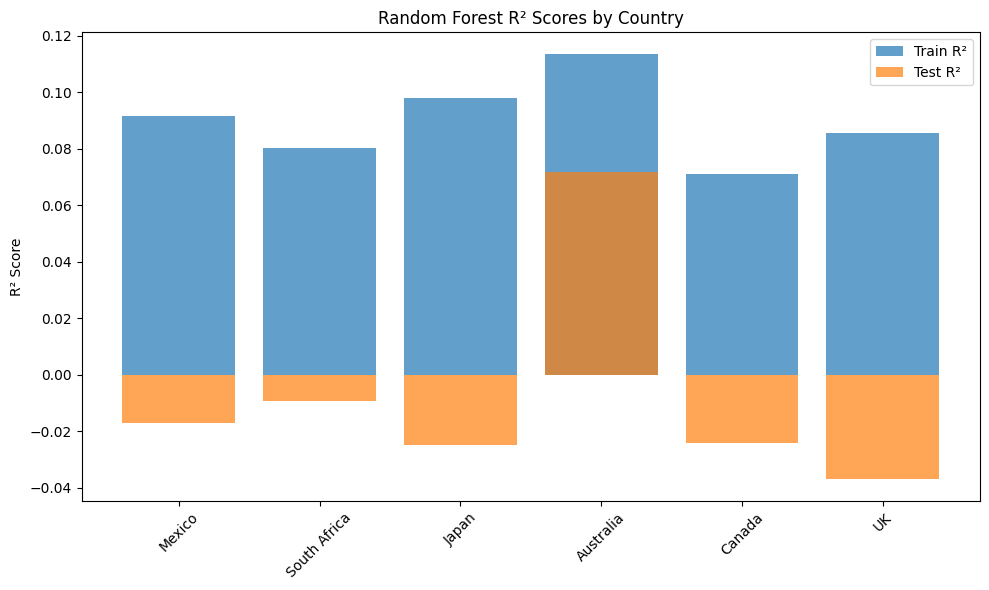

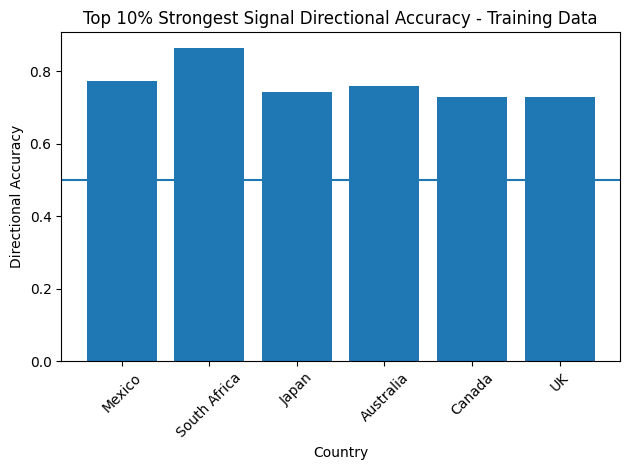

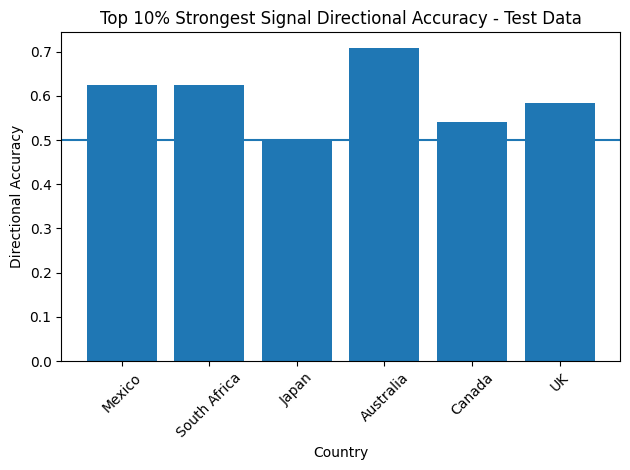

In [ ]:
train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}
train_thresholds = {}
test_thresholds = {}

for country, data in countries.items():
    if country not in country_residuals:
        print(f"\nResiduals for {country} not found. Skipping regression.")
        continue
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()
    df_train.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features
    
    X_test = countries[country]['2025-01-01':'2026-01-01']
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()
    df_test.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    print(f"\nRandom Forest Regression Results for {country}:")
    rf_predictions, rf_model_instance ,ys, train_r2, test_r2, strong_acc_train, strong_acc_test, train_threshold, test_threshold = random_forest_model(df_train.iloc[:, :-1], df_train.iloc[:, -1], df_test.iloc[:, :-1], df_test.iloc[:, -1])
    train_r2s[country] = train_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test
    train_thresholds[country] = train_threshold
    test_thresholds[country] = test_threshold



plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()


countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]
plt.figure()
plt.bar(countries2, values)
plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 10% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)
plt.axhline(0.5)
plt.tight_layout()
plt.show()

countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]
plt.figure()
plt.bar(countries2, values)
plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 10% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)
plt.axhline(0.5)
plt.tight_layout()
plt.show()
    